In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

veriler = pd.read_csv('ev_verisi.csv')
veriler.drop(index=14,inplace=True)
veriler

,ev_id,metrekare,oda_sayisi,bina_yasi,sehir_merkezi_uzakligi,fiyat
0,1,75,2,15,8,320000.0
1,2,120,3,5,3,650000.0
2,3,55,1,25,12,180000.0
3,4,200,5,2,1,1200000.0
4,5,90,3,10,5,450000.0
5,6,65,2,20,9,250000.0
6,7,150,4,8,4,780000.0
7,8,45,1,30,15,140000.0
8,9,175,4,3,2,950000.0
9,10,110,3,12,6,520000.0


In [3]:
#14. satırda nan değer olduğu için drop ettim
metrekare = veriler.iloc[:,1:2]
fiyat = veriler.iloc[:,5:6]




from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(metrekare,fiyat)


# plt.scatter(metrekare,fiyat,color='red')
# plt.plot(metrekare,lr.predict(metrekare))

tahmin=lr.predict([[160]])
tahmin

C:\Users\Görkem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[910571.85479861]])

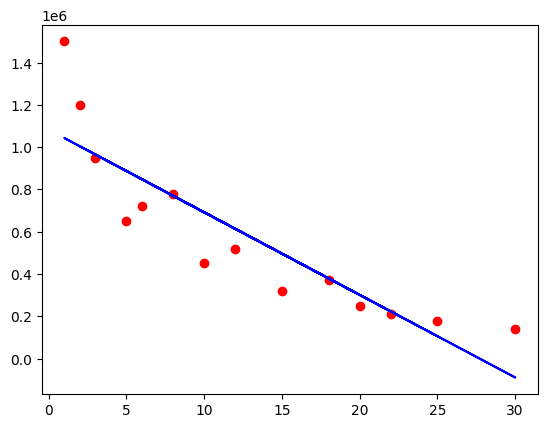

In [4]:
#Bina yaşından fiyat hesaplama
binaYasi = veriler.iloc[:,3:4]

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(binaYasi,fiyat)

#gerçek veri
plt.scatter(binaYasi,fiyat,color='red')
plt.plot(binaYasi,lr.predict(binaYasi),color='blue')


In [5]:
#Metrekare, oda_sayisi ve bina yasi ile fiyat hesaplama
oda_sayisi = veriler.iloc[:,2:3]
concatted_df= pd.concat([oda_sayisi,metrekare,binaYasi],axis=1)
concatted_df

from sklearn.linear_model import LinearRegression
lr_multi = LinearRegression()
lr_multi.fit(concatted_df,fiyat)

tahmin3=lr_multi.predict([[3,100,7]])
tahmin3

C:\Users\Görkem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[466942.95192832]])

In [6]:
lr_multi.coef_

array([[36963.49113096,  6764.562186  ,  4428.93969371]])

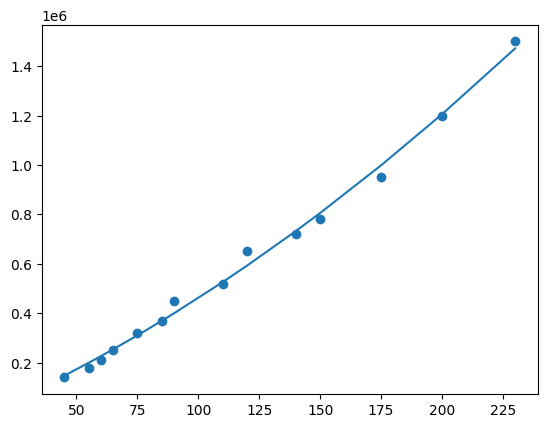

In [13]:
# Polinomal analiz (metrekare vs fiyat)
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
metrekare_poly = poly_reg.fit_transform(metrekare)

metrekare_poly
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(metrekare_poly,fiyat)
metrekare_sirali = metrekare.sort_values(by="metrekare")

plt.scatter(metrekare,fiyat)
plt.plot(metrekare_sirali,lr.predict(poly_reg.transform(metrekare_sirali)))